In [126]:
!pip install imbalanced-learn
!pip install kaggle
!pip install nltk

In [127]:
# =============================
# 1. Basic Libraries
# =============================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# Imbalance handling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [128]:
plt.style.use("ggplot")
sns.set_theme()

print("Environment setup successful!")

Environment setup successful!


In [129]:
# 2.Dataset Loading

import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b0043175b99990d58dfea31557cb48c3"

In [130]:
!pip install kagglehub

In [131]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("vstepanenko/disaster-tweets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'disaster-tweets' dataset.
Path to dataset files: /kaggle/input/disaster-tweets


In [132]:
import pandas as pd
import os

# load Dataset
df = pd.read_csv(os.path.join(path, "tweets.csv"))
df

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0
...,...,...,...,...,...
11365,11365,wrecked,Blue State in a red sea,Media should have warned us well in advance. T...,0
11366,11366,wrecked,arohaonces,i feel directly attacked 💀 i consider moonbin ...,0
11367,11367,wrecked,🇵🇭,i feel directly attacked 💀 i consider moonbin ...,0
11368,11368,wrecked,auroraborealis,"ok who remember ""outcast"" nd the ""dora"" au?? T...",0


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [134]:
df['target'].value_counts() # Check Class Distribution

,count
target,
0,9256
1,2114


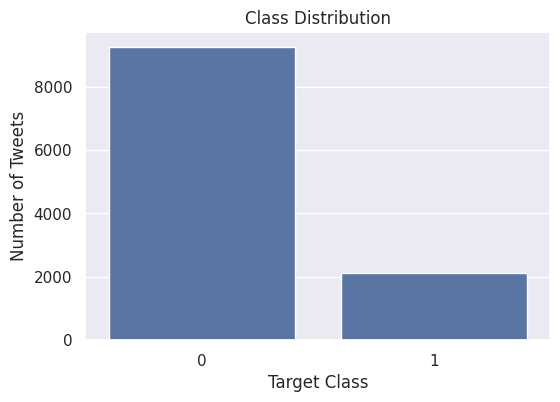

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Tweets")

plt.show()

In [136]:
# 3. Exploratory Data Analysis (EDA)
# =============================
# Purpose: Display dataset structure, column types, and non-null values
# =============================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [137]:
# =============================
# Purpose: Show statistical summary of numerical columns
# =============================

df.describe()

,id,target
count,11370.000000,11370.000000
mean,5684.500000,0.185928
std,3282.380615,0.389066
min,0.000000,0.000000
25%,2842.250000,0.000000
50%,5684.500000,0.000000
75%,8526.750000,0.000000
max,11369.000000,1.000000


In [138]:
# =============================
# Purpose: Check missing values in each column
# =============================

df.isnull().sum()

,0
id,0
keyword,0
location,3418
text,0
target,0


In [139]:
# =============================
# Purpose: Create a new feature for tweet length (number of characters)
# =============================

df['tweet_length'] = df['text'].apply(len)

df[['text', 'tweet_length']].head()

,text,tweet_length
0,"Communal violence in Bhainsa, Telangana. ""Ston...",125
1,Telangana: Section 144 has been imposed in Bha...,131
2,Arsonist sets cars ablaze at dealership https:...,63
3,Arsonist sets cars ablaze at dealership https:...,87
4,"""Lord Jesus, your love brings freedom and pard...",140


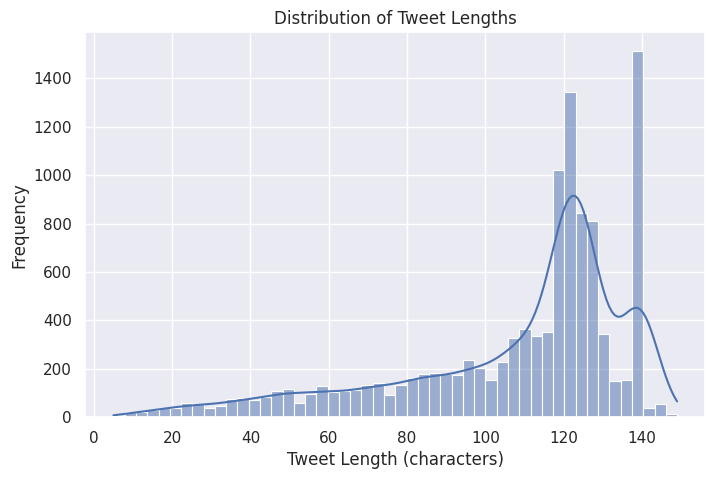

In [140]:
# =============================
# Purpose: Visualize distribution of tweet lengths
# =============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['tweet_length'], bins=50, kde=True)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Frequency")

plt.show()

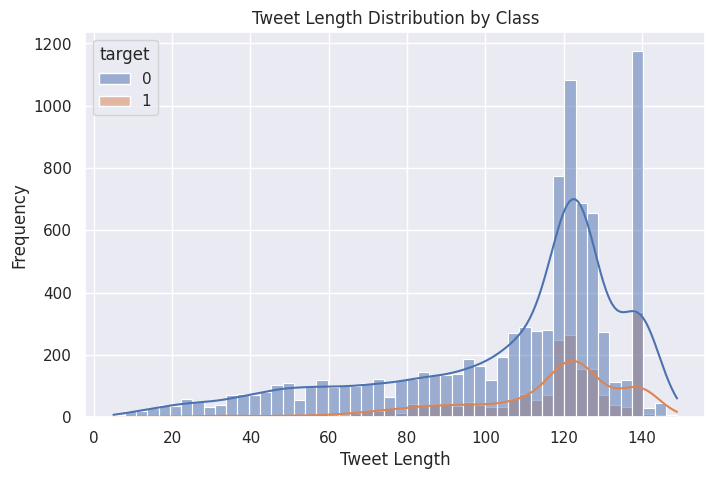

In [141]:
# =============================
# Purpose: Compare tweet length distribution between disaster and non-disaster tweets
# =============================

plt.figure(figsize=(8,5))

sns.histplot(data=df, x='tweet_length', hue='target', bins=50, kde=True)

plt.title("Tweet Length Distribution by Class")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

In [142]:
# =============================
# Purpose: Create a new feature for number of words in each tweet
# =============================

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

df[['text', 'word_count']].head()

,text,word_count
0,"Communal violence in Bhainsa, Telangana. ""Ston...",19
1,Telangana: Section 144 has been imposed in Bha...,23
2,Arsonist sets cars ablaze at dealership https:...,7
3,Arsonist sets cars ablaze at dealership https:...,8
4,"""Lord Jesus, your love brings freedom and pard...",23


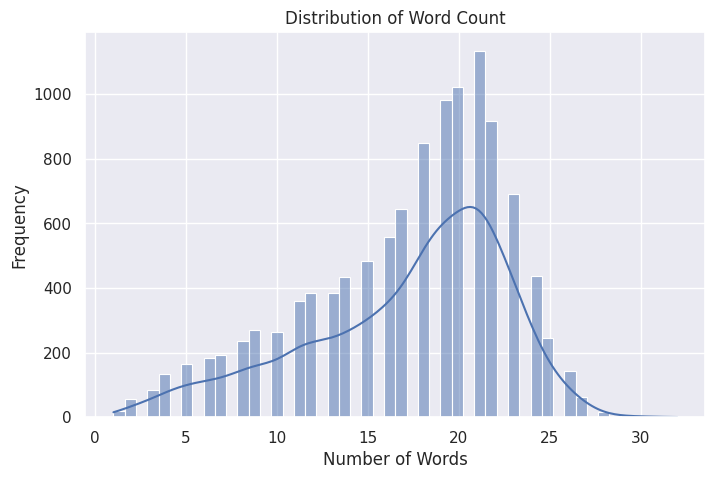

In [143]:
# =============================
# Purpose: Visualize distribution of word counts
# =============================

plt.figure(figsize=(8,5))

sns.histplot(df['word_count'], bins=50, kde=True)

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [144]:
# =============================
# Purpose: Find the most frequent words across all tweets
# =============================

from collections import Counter

all_words = " ".join(df['text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

common_words_df

,Word,Frequency
0,the,6314
1,to,4104
2,a,3642
3,of,3445
4,in,3089
5,and,2885
6,is,2153
7,I,1791
8,for,1531
9,on,1349


In [145]:
# =============================
# Purpose: Extract and analyze most frequent words in disaster tweets (target = 1)
# =============================

disaster_words = " ".join(df[df['target'] == 1]['text']).split()

disaster_freq = Counter(disaster_words).most_common(20)

disaster_df = pd.DataFrame(disaster_freq, columns=['Word', 'Frequency'])

disaster_df

,Word,Frequency
0,the,1163
1,in,954
2,of,689
3,to,634
4,a,629
5,and,541
6,on,319
7,is,262
8,at,243
9,for,220


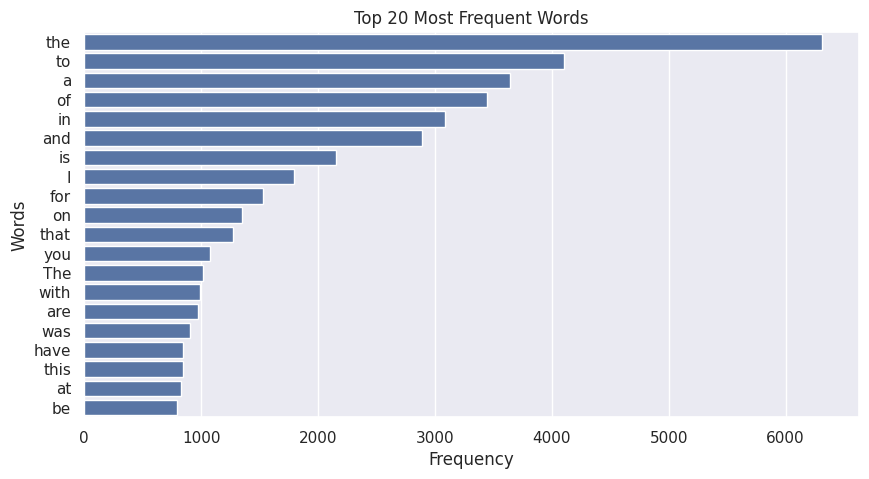

In [146]:
# =============================
# Purpose: Visualize top 20 most frequent words in all tweets
# =============================

plt.figure(figsize=(10,5))

sns.barplot(x='Frequency', y='Word', data=common_words_df)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [147]:
# =============================
# Purpose: Extract and analyze most frequent words in disaster tweets (target = 1)
# =============================

disaster_words = " ".join(df[df['target'] == 1]['text']).split()

disaster_freq = Counter(disaster_words).most_common(20)

disaster_df = pd.DataFrame(disaster_freq, columns=['Word', 'Frequency'])

disaster_df

,Word,Frequency
0,the,1163
1,in,954
2,of,689
3,to,634
4,a,629
5,and,541
6,on,319
7,is,262
8,at,243
9,for,220


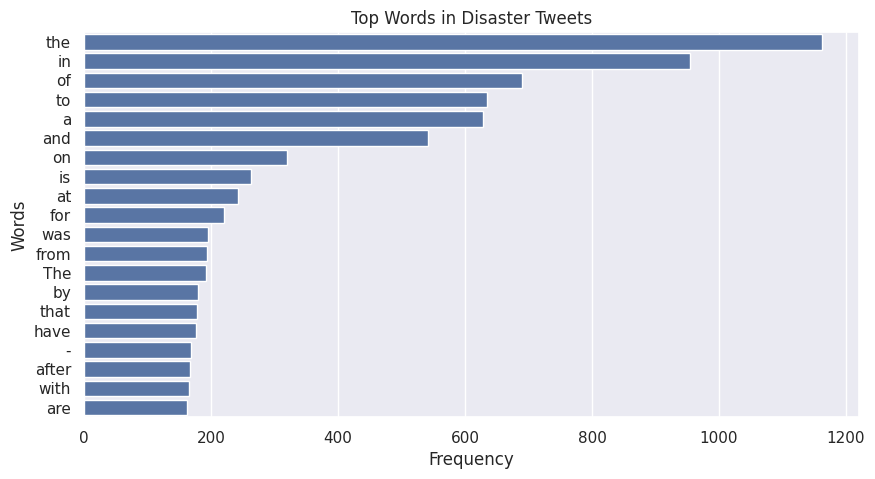

In [148]:
# =============================
# Purpose: Visualize most frequent words in disaster tweets
# =============================

plt.figure(figsize=(10,5))

sns.barplot(x='Frequency', y='Word', data=disaster_df)

plt.title("Top Words in Disaster Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [149]:
# =============================
# Purpose: Extract and analyze most frequent words in non-disaster tweets (target = 0)
# =============================

non_disaster_words = " ".join(df[df['target'] == 0]['text']).split()

non_disaster_freq = Counter(non_disaster_words).most_common(20)

non_disaster_df = pd.DataFrame(non_disaster_freq, columns=['Word', 'Frequency'])

non_disaster_df

,Word,Frequency
0,the,5151
1,to,3470
2,a,3013
3,of,2756
4,and,2344
5,in,2135
6,is,1891
7,I,1711
8,for,1311
9,that,1096


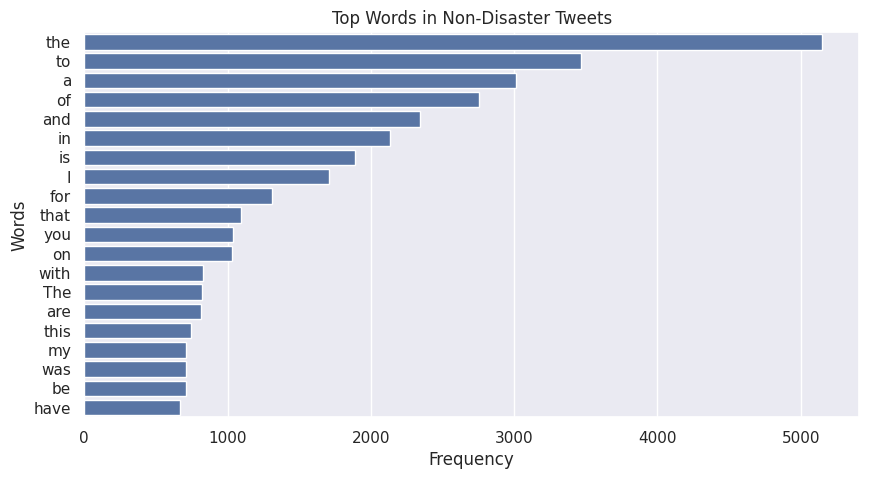

In [150]:
# =============================
# Purpose: Visualize most frequent words in non-disaster tweets
# =============================

plt.figure(figsize=(10,5))

sns.barplot(x='Frequency', y='Word', data=non_disaster_df)

plt.title("Top Words in Non-Disaster Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [151]:
# =============================
# 4 — TEXT PREPROCESSING
# Purpose: Import required libraries for text preprocessing
# =============================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [152]:
# =============================
# Purpose: Initialize stopwords and lemmatizer
# =============================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [153]:
# =============================
# Purpose: Define function to clean tweet text
# Steps:
# - convert to lowercase
# - remove URLs
# - remove punctuation
# - remove stopwords
# - apply lemmatization
# =============================

def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize text
    words = text.split()

    # remove stopwords and apply lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # join words back into sentence
    return " ".join(cleaned_words)

In [154]:
# =============================
# Purpose: Apply text preprocessing to entire dataset
# =============================

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']]

,text,clean_text
0,"Communal violence in Bhainsa, Telangana. ""Ston...",communal violence bhainsa telangana stone pelt...
1,Telangana: Section 144 has been imposed in Bha...,telangana section 144 imposed bhainsa january ...
2,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaze dealership
3,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaze dealership
4,"""Lord Jesus, your love brings freedom and pard...",lord jesus love brings freedom pardon fill hol...
...,...,...
11365,Media should have warned us well in advance. T...,medium warned u well advance wrecked whole nig...
11366,i feel directly attacked 💀 i consider moonbin ...,feel directly attacked 💀 consider moonbin amp ...
11367,i feel directly attacked 💀 i consider moonbin ...,feel directly attacked 💀 consider moonbin amp ...
11368,"ok who remember ""outcast"" nd the ""dora"" au?? T...",ok remember outcast nd dora au au wrecked nerv...


In [155]:
# =============================
# Purpose: Compare original vs cleaned text for verification
# =============================

for i in range(5):
    print("Original :", df['text'][i])
    print("Cleaned  :", df['clean_text'][i])
    print("-"*50)

Original : Communal violence in Bhainsa, Telangana. "Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…
Cleaned  : communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze…
--------------------------------------------------
Original : Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…
Cleaned  : telangana section 144 imposed bhainsa january 13 15 clash erupted two group january 12 po…
--------------------------------------------------
Original : Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI
Cleaned  : arsonist set car ablaze dealership
--------------------------------------------------
Original : Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9
Cleaned  : arsonist set car ablaze dealership
--------------------------------------------------
Original : "Lord Jesus, your love brings freedom 

In [156]:
# =============================
#5. TF-IDF Vectorization
# Purpose: Import TF-IDF vectorizer from sklearn
# =============================

from sklearn.feature_extraction.text import TfidfVectorizer

In [157]:
# =============================
# Purpose: Initialize TF-IDF vectorizer
# max_features: limits vocabulary size (helps reduce noise)
# =============================

vectorizer = TfidfVectorizer(max_features=5000)

In [158]:
# =============================
# Purpose: Convert cleaned text into numerical TF-IDF features
# X → feature matrix
# y → target labels
# =============================

X = vectorizer.fit_transform(df['clean_text'])

y = df['target']

In [159]:
# =============================
# Purpose: Check shape of feature matrix and target vector
# =============================

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (11370, 5000)
Shape of y (labels): (11370,)


In [160]:
# =============================
# Purpose: View sample feature names (words used in TF-IDF)
# =============================

feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])


['0019' '0100' '10' '100' '1000' '10000' '1010' '1033' '10am' '10year'
 '11' '110' '111' '112' '11th' '12' '120' '13' '13th' '14']


In [161]:
# 6 — Train-Test Split
# =============================
# Purpose: Import train_test_split function
# =============================

from sklearn.model_selection import train_test_split

In [162]:
# =============================
# Purpose: Split dataset into training and testing sets
# 80% training, 20% testing
# stratify=y ensures class distribution is preserved
# =============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [163]:
# =============================
# Purpose: Check shape of training and testing sets
# =============================

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9096, 5000)
X_test shape: (2274, 5000)
y_train shape: (9096,)
y_test shape: (2274,)


In [164]:
# =============================
# Purpose: Verify class distribution in training and testing sets
# =============================

print("Original distribution:\n", y.value_counts(normalize=True))
print("\nTraining distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting distribution:\n", y_test.value_counts(normalize=True))

Original distribution:
 target
0    0.814072
1    0.185928
Name: proportion, dtype: float64

Training distribution:
 target
0    0.814094
1    0.185906
Name: proportion, dtype: float64

Testing distribution:
 target
0    0.813984
1    0.186016
Name: proportion, dtype: float64


In [165]:
# =============================
#7. Train Models
# Purpose: Create a list to store model performance for comparison later
# =============================

results = []

In [166]:
# =============================
# Purpose: Import models and evaluation metrics
# =============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score
)

In [167]:
# =============================
# Purpose: Train Logistic Regression model (baseline, no imbalance handling)
# =============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [168]:
# =============================
# Purpose: Predict using Logistic Regression model
# =============================

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [169]:
.32# =============================
# Purpose: Evaluate Logistic Regression model
# =============================

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("Accuracy:", acc_lr)
print("F1 (Macro):", f1_lr)
print("ROC-AUC:", roc_lr)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8645558487247141
F1 (Macro): 0.7009366545514168
ROC-AUC: 0.903405353696743

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.99      0.92      1851
           1       0.84      0.34      0.48       423

    accuracy                           0.86      2274
   macro avg       0.85      0.66      0.70      2274
weighted avg       0.86      0.86      0.84      2274



In [170]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Calculate additional metrics for Logistic Regression
precision_lr_macro = precision_score(y_test, y_pred_lr, average='macro')
recall_lr_macro = recall_score(y_test, y_pred_lr, average='macro')
f1_lr_weighted = f1_score(y_test, y_pred_lr, average='weighted')
precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_lr_curve, precision_lr_curve)

# Store Logistic Regression results
results.append({
    "Model": "Logistic Regression",
    "Technique": "None",
    "Accuracy": acc_lr,
    "Macro_F1": f1_lr,
    "Weighted_F1": f1_lr_weighted,
    "Precision_Macro": precision_lr_macro,
    "Recall_Macro": recall_lr_macro,
    "ROC_AUC": roc_lr,
    "PR_AUC": pr_auc_lr
})

In [171]:
# =============================
# Purpose: Train Random Forest model (baseline)
# =============================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [172]:
# =============================
# Purpose: Predict using Random Forest model
# =============================

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [173]:
# =============================
# Purpose: Evaluate Random Forest model
# =============================

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy:", acc_rf)
print("F1 (Macro):", f1_rf)
print("ROC-AUC:", roc_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8773087071240105
F1 (Macro): 0.7596608827579414
ROC-AUC: 0.8910664863283919

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1851
           1       0.78      0.48      0.59       423

    accuracy                           0.88      2274
   macro avg       0.83      0.72      0.76      2274
weighted avg       0.87      0.88      0.87      2274



In [174]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Calculate additional metrics for Random Forest
precision_rf_macro = precision_score(y_test, y_pred_rf, average='macro')
recall_rf_macro = recall_score(y_test, y_pred_rf, average='macro')
f1_rf_weighted = f1_score(y_test, y_pred_rf, average='weighted')
precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf_curve, precision_rf_curve)

# Store Random Forest results
results.append({
    "Model": "Random Forest",
    "Technique": "None",
    "Accuracy": acc_rf,
    "Macro_F1": f1_rf,
    "Weighted_F1": f1_rf_weighted,
    "Precision_Macro": precision_rf_macro,
    "Recall_Macro": recall_rf_macro,
    "ROC_AUC": roc_rf,
    "PR_AUC": pr_auc_rf
})

In [175]:
# This cell is a duplicate and will be removed.

In [176]:
# =============================
# Purpose: Convert sparse matrix to dense for Neural Network
# =============================

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [177]:
# =============================
# Purpose: Define a function to build the Neural Network model
# =============================

from tensorflow.keras.layers import Input

def build_nn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the baseline Neural Network model
nn_model = build_nn(X_train_dense.shape[1])

In [178]:
# This cell is now integrated into the `build_nn` function and is no longer needed separately. It will be removed.

In [54]:
# =============================
# Purpose: Train Neural Network model
# =============================

nn_model.fit(
    X_train_dense, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8379 - loss: 0.4098 - val_accuracy: 0.8835 - val_loss: 0.3318
Epoch 2/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9221 - loss: 0.2009 - val_accuracy: 0.8791 - val_loss: 0.3473
Epoch 3/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9653 - loss: 0.1020 - val_accuracy: 0.8725 - val_loss: 0.4162
Epoch 4/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9862 - loss: 0.0471 - val_accuracy: 0.8780 - val_loss: 0.5055
Epoch 5/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9929 - loss: 0.0207 - val_accuracy: 0.8703 - val_loss: 0.6450


In [55]:
# =============================
# Purpose: Predict using Neural Network model
# =============================

y_prob_nn = nn_model.predict(X_test_dense)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [56]:
# =============================
# Purpose: Evaluate Neural Network model
# =============================

acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average='macro')
roc_nn = roc_auc_score(y_test, y_prob_nn)

print("Neural Network Results")
print("Accuracy:", acc_nn)
print("F1 (Macro):", f1_nn)
print("ROC-AUC:", roc_nn)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nn))

Neural Network Results
Accuracy: 0.8720316622691293
F1 (Macro): 0.7777712104751462
ROC-AUC: 0.869898451159874

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1851
           1       0.68      0.59      0.63       423

    accuracy                           0.87      2274
   macro avg       0.79      0.76      0.78      2274
weighted avg       0.87      0.87      0.87      2274



In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Calculate additional metrics for Neural Network
precision_nn_macro = precision_score(y_test, y_pred_nn, average='macro')
recall_nn_macro = recall_score(y_test, y_pred_nn, average='macro')
f1_nn_weighted = f1_score(y_test, y_pred_nn, average='weighted')
precision_nn_curve, recall_nn_curve, _ = precision_recall_curve(y_test, y_prob_nn.flatten())
pr_auc_nn = auc(recall_nn_curve, precision_nn_curve)

# Store Neural Network results
results.append({
    "Model": "Neural Network",
    "Technique": "None",
    "Accuracy": acc_nn,
    "Macro_F1": f1_nn,
    "Weighted_F1": f1_nn_weighted,
    "Precision_Macro": precision_nn_macro,
    "Recall_Macro": recall_nn_macro,
    "ROC_AUC": roc_nn,
    "PR_AUC": pr_auc_nn
})

In [58]:
# =============================
# Purpose: Convert results into DataFrame for comparison
# =============================

import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236


In [59]:
# =============================
#8. Detailed Evaluation & Plots
# Purpose: Import libraries for evaluation and plotting
# =============================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

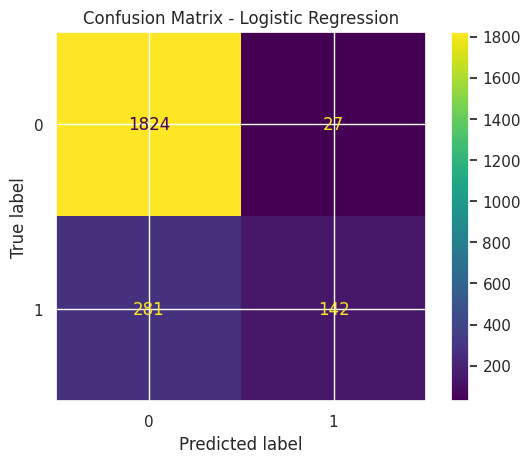

In [60]:
# =============================
# Purpose: Plot confusion matrix for Logistic Regression
# =============================

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

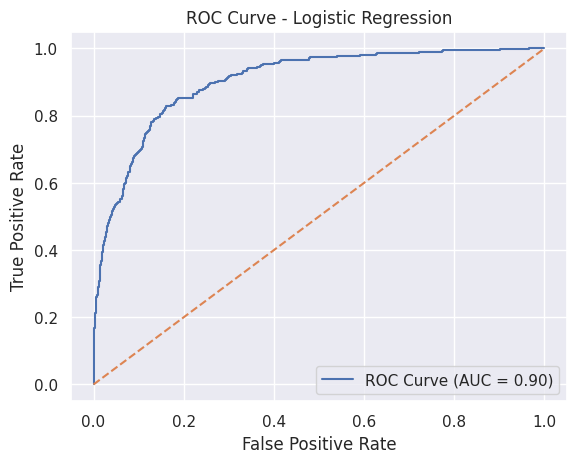

In [61]:
# =============================
# Purpose: Plot ROC curve for Logistic Regression
# =============================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"ROC Curve (AUC = {roc_auc_lr:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

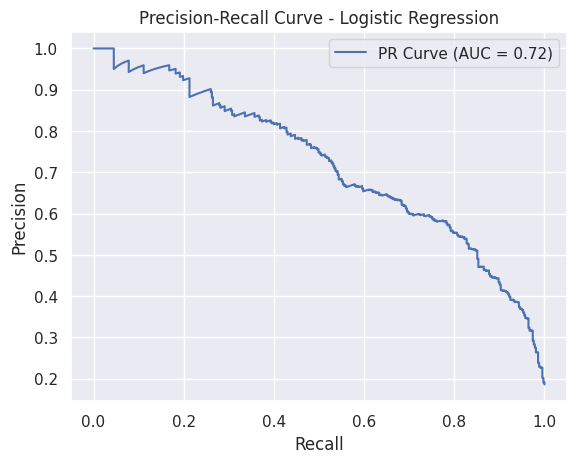

In [62]:
# =============================
# Purpose: Plot Precision-Recall curve and compute PR-AUC
# =============================

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

plt.figure()

plt.plot(recall_lr, precision_lr, label=f"PR Curve (AUC = {pr_auc_lr:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.legend()
plt.show()

In [63]:
results.append({
    "Model": "Logistic Regression",
    "Technique": "None",
    "Accuracy": acc_lr,
    "Macro_F1": f1_lr,
    "Weighted_F1": f1_lr_weighted,
    "Precision_Macro": precision_lr_macro,
    "Recall_Macro": recall_lr_macro,
    "ROC_AUC": roc_lr,
    "PR_AUC": pr_auc_lr
})

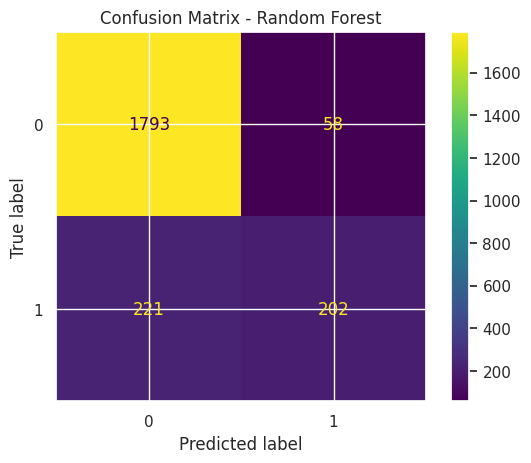

In [64]:
# =============================
# Purpose: Confusion Matrix - Random Forest
# =============================

cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm_rf).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

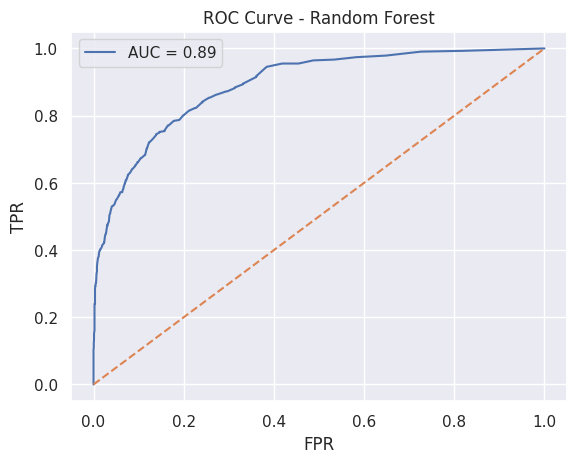

In [65]:
# =============================
# Purpose: ROC Curve - Random Forest
# =============================

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.legend()
plt.show()

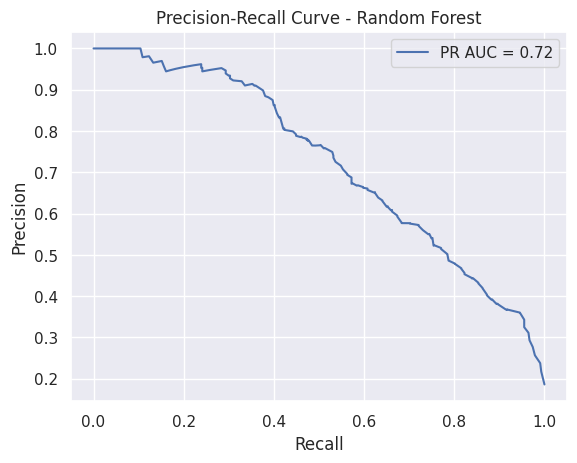

In [66]:
# =============================
# Purpose: Precision-Recall Curve - Random Forest
# =============================

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

plt.figure()

plt.plot(recall_rf, precision_rf, label=f"PR AUC = {pr_auc_rf:.2f}")

plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.show()

In [67]:
# This cell is redundant as metrics are now calculated within each model's block and will be removed.

In [68]:
# This cell is a duplicate and will be removed.

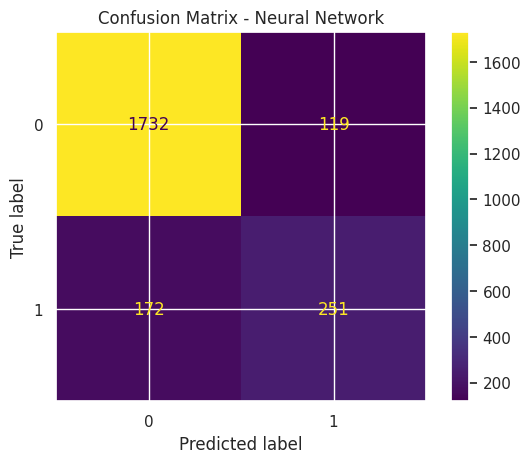

In [69]:
# =============================
# Purpose: Confusion Matrix - Neural Network
# =============================

cm_nn = confusion_matrix(y_test, y_pred_nn)

ConfusionMatrixDisplay(cm_nn).plot()

plt.title("Confusion Matrix - Neural Network")
plt.show()

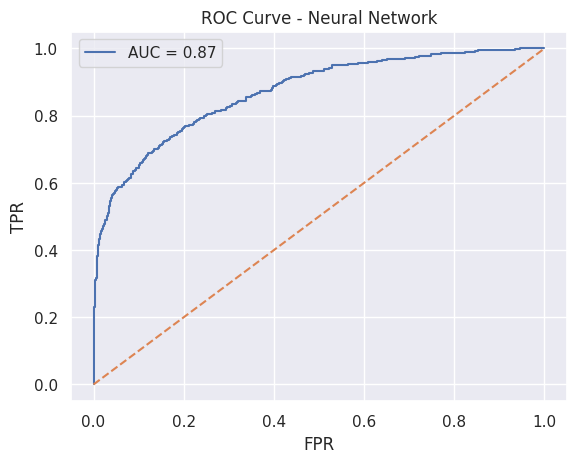

In [70]:
# =============================
# Purpose: ROC Curve - Neural Network
# =============================

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure()

plt.plot(fpr_nn, tpr_nn, label=f"AUC = {roc_auc_nn:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Neural Network")
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.legend()
plt.show()

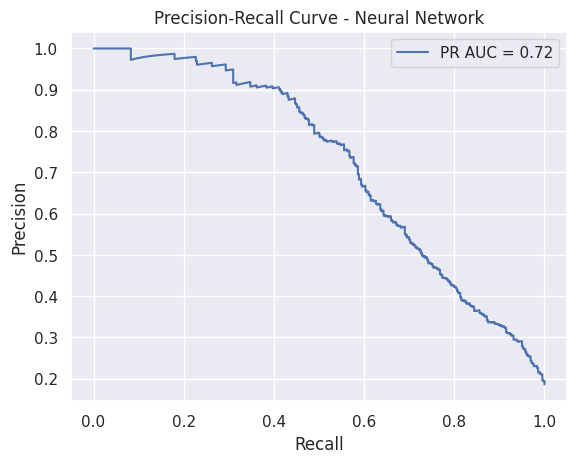

In [71]:
# =============================
# Purpose: Precision-Recall Curve - Neural Network
# =============================

precision_nn, recall_nn, _ = precision_recall_curve(y_test, y_prob_nn)
pr_auc_nn = auc(recall_nn, precision_nn)

plt.figure()

plt.plot(recall_nn, precision_nn, label=f"PR AUC = {pr_auc_nn:.2f}")

plt.title("Precision-Recall Curve - Neural Network")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.show()

In [72]:
# This cell is redundant as metrics are now calculated within each model's block and will be removed.

In [73]:
# This cell is a duplicate and will be removed.

In [74]:
results_df = pd.DataFrame(results).drop_duplicates(subset=['Model', 'Technique']).reset_index(drop=True)
results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236


In [75]:
# =============================
# 9. With Imbalance Handling
# Technique 1 : Class Weighting
# Purpose: Train Logistic Regression with class weighting
# =============================

lr_cw = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_cw.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Predict and evaluate Logistic Regression (Class Weight)
y_pred_lr_cw = lr_cw.predict(X_test)
y_prob_lr_cw = lr_cw.predict_proba(X_test)[:, 1]

acc_lr_cw = accuracy_score(y_test, y_pred_lr_cw)
f1_lr_cw = f1_score(y_test, y_pred_lr_cw, average='macro')
roc_lr_cw = roc_auc_score(y_test, y_prob_lr_cw)

# Calculate additional metrics for LR + Class Weight
precision_lr_cw_macro = precision_score(y_test, y_pred_lr_cw, average='macro')
recall_lr_cw_macro = recall_score(y_test, y_pred_lr_cw, average='macro')
f1_lr_cw_weighted = f1_score(y_test, y_pred_lr_cw, average='weighted')
precision_lr_cw_curve, recall_lr_cw_curve, _ = precision_recall_curve(y_test, y_prob_lr_cw)
pr_auc_lr_cw = auc(recall_lr_cw_curve, precision_lr_cw_curve)

print("LR + Class Weight")
print("Accuracy:", acc_lr_cw)
print("F1:", f1_lr_cw)
print("ROC-AUC:", roc_lr_cw)

LR + Class Weight
Accuracy: 0.8522427440633246
F1: 0.7788511410788381
ROC-AUC: 0.903457718209951


In [77]:
# Store results (LR + Class Weight)
results.append({
    "Model": "Logistic Regression",
    "Technique": "Class Weight",
    "Accuracy": acc_lr_cw,
    "Macro_F1": f1_lr_cw,
    "Weighted_F1": f1_lr_cw_weighted,
    "Precision_Macro": precision_lr_cw_macro,
    "Recall_Macro": recall_lr_cw_macro,
    "ROC_AUC": roc_lr_cw,
    "PR_AUC": pr_auc_lr_cw
})

In [78]:
# =============================
# Purpose: Train Random Forest with class weighting
# =============================

rf_cw = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_cw.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Evaluate Random Forest (Class Weight)
y_pred_rf_cw = rf_cw.predict(X_test)
y_prob_rf_cw = rf_cw.predict_proba(X_test)[:, 1]

acc_rf_cw = accuracy_score(y_test, y_pred_rf_cw)
f1_rf_cw = f1_score(y_test, y_pred_rf_cw, average='macro')
roc_rf_cw = roc_auc_score(y_test, y_prob_rf_cw)

# Calculate additional metrics for RF + Class Weight
precision_rf_cw_macro = precision_score(y_test, y_pred_rf_cw, average='macro')
recall_rf_cw_macro = recall_score(y_test, y_pred_rf_cw, average='macro')
f1_rf_cw_weighted = f1_score(y_test, y_pred_rf_cw, average='weighted')
precision_rf_cw_curve, recall_rf_cw_curve, _ = precision_recall_curve(y_test, y_prob_rf_cw)
pr_auc_rf_cw = auc(recall_rf_cw_curve, precision_rf_cw_curve)

print("RF + Class Weight")
print("Accuracy:", acc_rf_cw)
print("F1:", f1_rf_cw)
print("ROC-AUC:", roc_rf_cw)

RF + Class Weight
Accuracy: 0.8786279683377308
F1: 0.7608012622624682
ROC-AUC: 0.90206303410207


In [80]:
results.append({
    "Model": "Random Forest",
    "Technique": "Class Weight",
    "Accuracy": acc_rf_cw,
    "Macro_F1": f1_rf_cw,
    "Weighted_F1": f1_rf_cw_weighted,
    "Precision_Macro": precision_rf_cw_macro,
    "Recall_Macro": recall_rf_cw_macro,
    "ROC_AUC": roc_rf_cw,
    "PR_AUC": pr_auc_rf_cw
})

In [81]:
# =============================
# Purpose: Define class weights for Neural Network
# =============================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print(class_weights_dict)

{0: np.float64(0.6141796083727211), 1: np.float64(2.689532820816085)}


In [82]:
# =============================
# Purpose: Train Neural Network with class weights
# =============================

# Re-initialize the NN model for class weighting to ensure independent training
nn_model_cw = build_nn(X_train_dense.shape[1])

nn_model_cw.fit(
    X_train_dense, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights_dict
)

Epoch 1/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8165 - loss: 0.5592 - val_accuracy: 0.7440 - val_loss: 0.5127
Epoch 2/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8932 - loss: 0.2665 - val_accuracy: 0.8495 - val_loss: 0.3688
Epoch 3/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9509 - loss: 0.1332 - val_accuracy: 0.8571 - val_loss: 0.4358
Epoch 4/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9742 - loss: 0.0655 - val_accuracy: 0.8593 - val_loss: 0.5095
Epoch 5/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9882 - loss: 0.0325 - val_accuracy: 0.8714 - val_loss: 0.6419


In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Evaluate Neural Network (Class Weight)
y_prob_nn_cw = nn_model_cw.predict(X_test_dense) # Use the class-weighted model here
y_pred_nn_cw = (y_prob_nn_cw > 0.5).astype(int)

acc_nn_cw = accuracy_score(y_test, y_pred_nn_cw)
f1_nn_cw = f1_score(y_test, y_pred_nn_cw, average='macro')
roc_nn_cw = roc_auc_score(y_test, y_prob_nn_cw)

# Calculate additional metrics for NN + Class Weight
precision_nn_cw_macro = precision_score(y_test, y_pred_nn_cw, average='macro')
recall_nn_cw_macro = recall_score(y_test, y_pred_nn_cw, average='macro')
f1_nn_cw_weighted = f1_score(y_test, y_pred_nn_cw, average='weighted')
precision_nn_cw_curve, recall_nn_cw_curve, _ = precision_recall_curve(y_test, y_prob_nn_cw.flatten())
pr_auc_nn_cw = auc(recall_nn_cw_curve, precision_nn_cw_curve)

print("NN + Class Weight")
print("Accuracy:", acc_nn_cw)
print("F1:", f1_nn_cw)
print("ROC-AUC:", roc_nn_cw)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NN + Class Weight
Accuracy: 0.8676341248900615
F1: 0.7696759559147408
ROC-AUC: 0.8585034222125156


In [84]:
results.append({
    "Model": "Neural Network",
    "Technique": "Class Weight",
    "Accuracy": acc_nn_cw,
    "Macro_F1": f1_nn_cw,
    "Weighted_F1": f1_nn_cw_weighted,
    "Precision_Macro": precision_nn_cw_macro,
    "Recall_Macro": recall_nn_cw_macro,
    "ROC_AUC": roc_nn_cw,
    "PR_AUC": pr_auc_nn_cw
})

In [85]:
# =============================
# Technique 2 :Purpose: Import SMOTE
# =============================

from imblearn.over_sampling import SMOTE

In [86]:
# =============================
# Purpose: Apply SMOTE on training data ONLY
# =============================

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: target
0    7405
1    1691
Name: count, dtype: int64
After SMOTE: target
0    7405
1    7405
Name: count, dtype: int64


In [87]:
# =============================
# Purpose: Train Logistic Regression on SMOTE data
# =============================

lr_sm = LogisticRegression(max_iter=1000)

lr_sm.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

In [88]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

# Evaluate LR (SMOTE)
y_pred_lr_sm = lr_sm.predict(X_test)
y_prob_lr_sm = lr_sm.predict_proba(X_test)[:, 1]

acc_lr_sm = accuracy_score(y_test, y_pred_lr_sm)
f1_lr_sm = f1_score(y_test, y_pred_lr_sm, average='macro')
roc_lr_sm = roc_auc_score(y_test, y_prob_lr_sm)

# Calculate additional metrics for LR + SMOTE
precision_lr_sm_macro = precision_score(y_test, y_pred_lr_sm, average='macro')
recall_lr_sm_macro = recall_score(y_test, y_pred_lr_sm, average='macro')
f1_lr_sm_weighted = f1_score(y_test, y_pred_lr_sm, average='weighted')
precision_lr_sm_curve, recall_lr_sm_curve, _ = precision_recall_curve(y_test, y_prob_lr_sm)
pr_auc_lr_sm = auc(recall_lr_sm_curve, precision_lr_sm_curve)

print("LR + SMOTE")
print("Accuracy:", acc_lr_sm)
print("F1:", f1_lr_sm)
print("ROC-AUC:", roc_lr_sm)

LR + SMOTE
Accuracy: 0.8592788038698329
F1: 0.7809166768027227
ROC-AUC: 0.9015049050222679


In [89]:
results.append({
    "Model": "Logistic Regression",
    "Technique": "SMOTE",
    "Accuracy": acc_lr_sm,
    "Macro_F1": f1_lr_sm,
    "Weighted_F1": f1_lr_sm_weighted,
    "Precision_Macro": precision_lr_sm_macro,
    "Recall_Macro": recall_lr_sm_macro,
    "ROC_AUC": roc_lr_sm,
    "PR_AUC": pr_auc_lr_sm
})

In [90]:
rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [91]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

y_pred_rf_sm = rf_sm.predict(X_test)
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:, 1]

acc_rf_sm = accuracy_score(y_test, y_pred_rf_sm)
f1_rf_sm = f1_score(y_test, y_pred_rf_sm, average='macro')
roc_rf_sm = roc_auc_score(y_test, y_prob_rf_sm)

# Calculate additional metrics for RF + SMOTE
precision_rf_sm_macro = precision_score(y_test, y_pred_rf_sm, average='macro')
recall_rf_sm_macro = recall_score(y_test, y_pred_rf_sm, average='macro')
f1_rf_sm_weighted = f1_score(y_test, y_pred_rf_sm, average='weighted')
precision_rf_sm_curve, recall_rf_sm_curve, _ = precision_recall_curve(y_test, y_prob_rf_sm)
pr_auc_rf_sm = auc(recall_rf_sm_curve, precision_rf_sm_curve)

print("RF + SMOTE")
print("Accuracy:", acc_rf_sm)
print("F1:", f1_rf_sm)
print("ROC-AUC:", roc_rf_sm)

RF + SMOTE
Accuracy: 0.882145998240985
F1: 0.7846663953054509
ROC-AUC: 0.9085868861378362


In [92]:
results.append({
    "Model": "Random Forest",
    "Technique": "SMOTE",
    "Accuracy": acc_rf_sm,
    "Macro_F1": f1_rf_sm,
    "Weighted_F1": f1_rf_sm_weighted,
    "Precision_Macro": precision_rf_sm_macro,
    "Recall_Macro": recall_rf_sm_macro,
    "ROC_AUC": roc_rf_sm,
    "PR_AUC": pr_auc_rf_sm
})

In [93]:
# convert SMOTE data to dense
X_train_sm_dense = X_train_sm.toarray()

In [94]:
# =============================
# Purpose: Train Neural Network with SMOTE data
# =============================

# Re-initialize the NN model for SMOTE to ensure independent training
nn_model_sm = build_nn(X_train_sm_dense.shape[1])

nn_model_sm.fit(
    X_train_sm_dense, y_train_sm,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8518 - loss: 0.3268 - val_accuracy: 0.9784 - val_loss: 0.0883
Epoch 2/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9668 - loss: 0.1007 - val_accuracy: 0.9885 - val_loss: 0.0645
Epoch 3/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9877 - loss: 0.0419 - val_accuracy: 0.9973 - val_loss: 0.0165
Epoch 4/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9949 - loss: 0.0200 - val_accuracy: 0.9946 - val_loss: 0.0239
Epoch 5/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9970 - loss: 0.0129 - val_accuracy: 0.9980 - val_loss: 0.0062


In [95]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

y_prob_nn_sm = nn_model_sm.predict(X_test_dense) # Use the SMOTE-trained model here
y_pred_nn_sm = (y_prob_nn_sm > 0.5).astype(int)

acc_nn_sm = accuracy_score(y_test, y_pred_nn_sm)
f1_nn_sm = f1_score(y_test, y_pred_nn_sm, average='macro')
roc_nn_sm = roc_auc_score(y_test, y_prob_nn_sm)

# Calculate additional metrics for NN + SMOTE
precision_nn_sm_macro = precision_score(y_test, y_pred_nn_sm, average='macro')
recall_nn_sm_macro = recall_score(y_test, y_pred_nn_sm, average='macro')
f1_nn_sm_weighted = f1_score(y_test, y_pred_nn_sm, average='weighted')
precision_nn_sm_curve, recall_nn_sm_curve, _ = precision_recall_curve(y_test, y_prob_nn_sm.flatten())
pr_auc_nn_sm = auc(recall_nn_sm_curve, precision_nn_sm_curve)

print("NN + SMOTE")
print("Accuracy:", acc_nn_sm)
print("F1:", f1_nn_sm)
print("ROC-AUC:", roc_nn_sm)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NN + SMOTE
Accuracy: 0.8693931398416886
F1: 0.7792786418494659
ROC-AUC: 0.8715568736086686


In [96]:
results.append({
    "Model": "Neural Network",
    "Technique": "SMOTE",
    "Accuracy": acc_nn_sm,
    "Macro_F1": f1_nn_sm,
    "Weighted_F1": f1_nn_sm_weighted,
    "Precision_Macro": precision_nn_sm_macro,
    "Recall_Macro": recall_nn_sm_macro,
    "ROC_AUC": roc_nn_sm,
    "PR_AUC": pr_auc_nn_sm
})

In [97]:
# 10. Compare All Models
# =============================
# Purpose: Convert results list into structured DataFrame
# =============================

results_df = pd.DataFrame(results)

results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192


In [98]:
# =============================
# Purpose: Sort models by Macro F1 score (important for imbalance)
# =============================

results_df_sorted = results_df.sort_values(by="Macro_F1", ascending=False)

results_df_sorted

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160


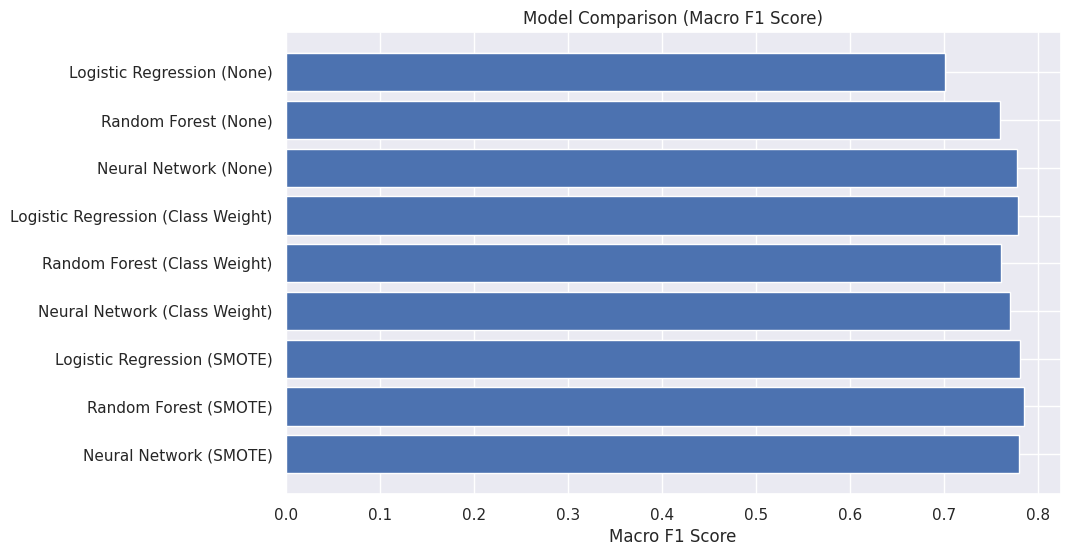

In [99]:
# =============================
# Purpose: Visualize model comparison using Macro F1 score
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['Macro_F1'])

plt.xlabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")

plt.gca().invert_yaxis()
plt.show()

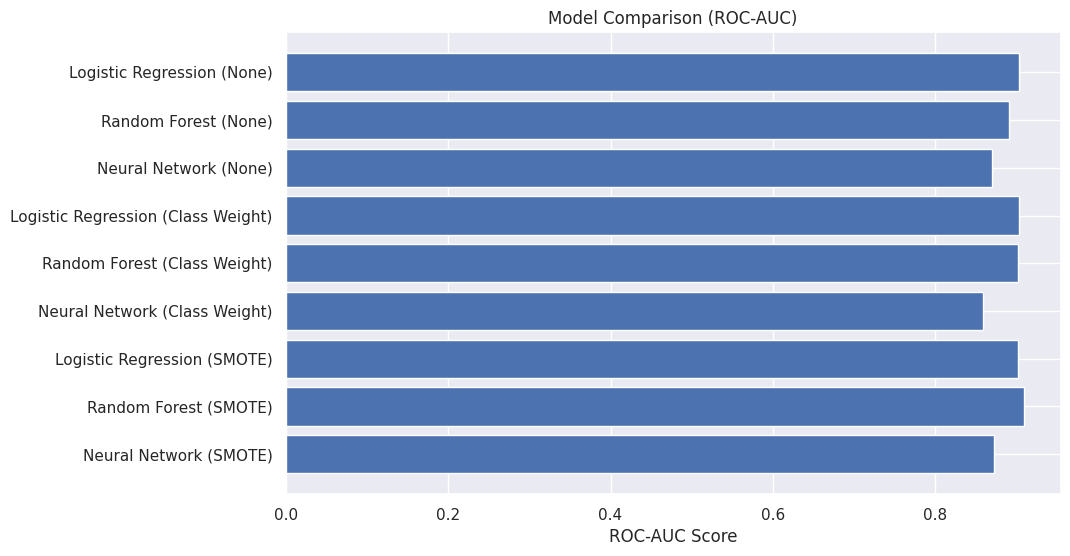

In [100]:
# =============================
# Purpose: Visualize comparison using ROC-AUC
# =============================

plt.figure(figsize=(10,6))

labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['ROC_AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (ROC-AUC)")

plt.gca().invert_yaxis()
plt.show()

In [101]:
# =============================
# Purpose: Identify best performing model
# =============================

best_model = results_df_sorted.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Technique                  SMOTE
Accuracy                0.882146
Macro_F1                0.784666
Weighted_F1             0.875647
Precision_Macro         0.823353
Recall_Macro            0.758904
ROC_AUC                 0.908587
PR_AUC                  0.748312
Name: 8, dtype: object


In [102]:
# =============================
# Purpose: Perform Hyperparameter Tuning for Random Forest Classifier using GridSearchCV
# =============================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve, auc

# Define parameter grid for Random Forest
# Keeping the grid small for demonstration and faster execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
# Using 'f1_macro' as the scoring metric due to class imbalance
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3, # Using 3-fold cross-validation for speed
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the SMOTE-resampled training data
# Since RF with SMOTE performed best, we will tune that combination
print("Starting Grid Search for Random Forest...")
grid_search_rf.fit(X_train_sm, y_train_sm)
print("Grid Search complete.")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("\nBest parameters found:", grid_search_rf.best_params_)

# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro')
roc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

# Calculate additional metrics for Tuned RF
precision_rf_tuned_macro = precision_score(y_test, y_pred_rf_tuned, average='macro')
recall_rf_tuned_macro = recall_score(y_test, y_pred_rf_tuned, average='macro')
f1_rf_tuned_weighted = f1_score(y_test, y_pred_rf_tuned, average='weighted')
precision_rf_tuned_curve, recall_rf_tuned_curve, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc_rf_tuned = auc(recall_rf_tuned_curve, precision_rf_tuned_curve)

print("\nTuned Random Forest Results")
print("Accuracy:", acc_rf_tuned)
print("F1 (Macro):", f1_rf_tuned)
print("ROC-AUC:", roc_rf_tuned)

# Store results
results.append({
    "Model": "Random Forest",
    "Technique": "SMOTE + Tuned",
    "Accuracy": acc_rf_tuned,
    "Macro_F1": f1_rf_tuned,
    "Weighted_F1": f1_rf_tuned_weighted,
    "Precision_Macro": precision_rf_tuned_macro,
    "Recall_Macro": recall_rf_tuned_macro,
    "ROC_AUC": roc_rf_tuned,
    "PR_AUC": pr_auc_rf_tuned
})


Starting Grid Search for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid Search complete.

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Tuned Random Forest Results
Accuracy: 0.8548812664907651
F1 (Macro): 0.7331156776134691
ROC-AUC: 0.8451715448680863


In [103]:
results_df = pd.DataFrame(results)
results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192


In [104]:
# =============================
# Purpose: Sort models by Macro F1 score (important for imbalance)
# =============================

results_df_sorted = results_df.sort_values(by="Macro_F1", ascending=False)

results_df_sorted

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
10,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160


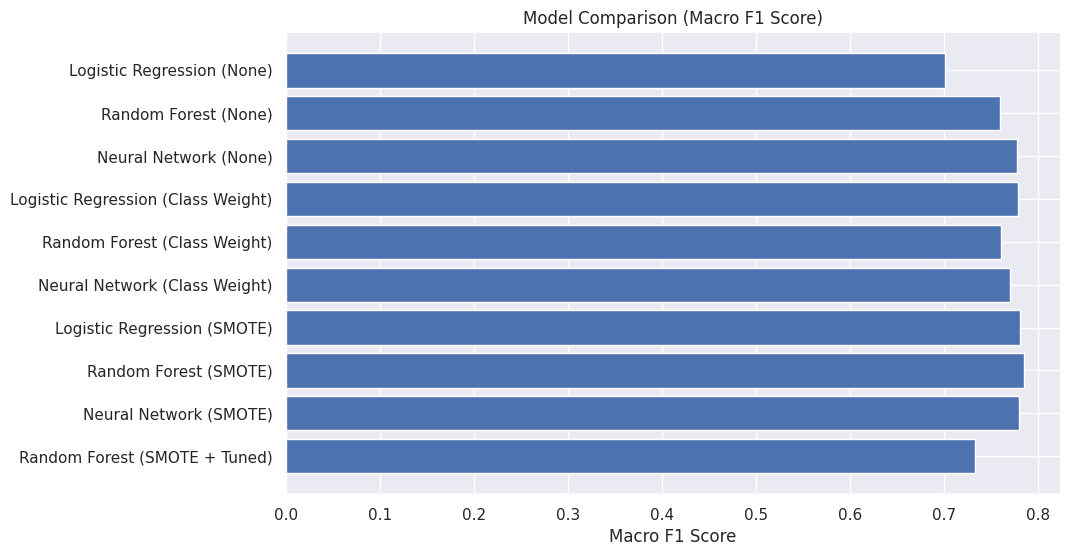

In [105]:
# =============================
# Purpose: Visualize model comparison using Macro F1 score
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['Macro_F1'])

plt.xlabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")

plt.gca().invert_yaxis()
plt.show()

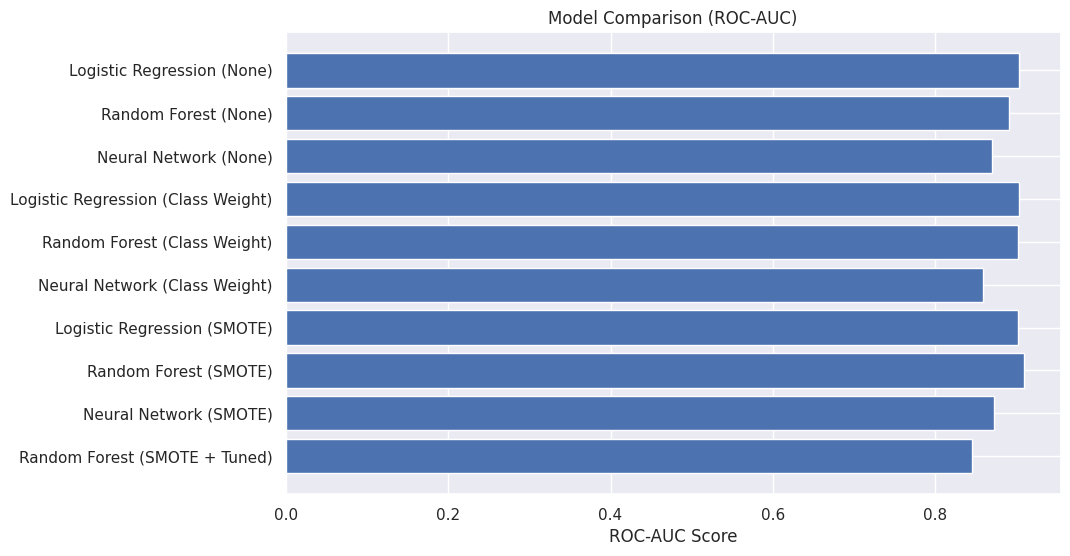

In [106]:
# =============================
# Purpose: Visualize comparison using ROC-AUC
# =============================

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['ROC_AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (ROC-AUC)")

plt.gca().invert_yaxis()
plt.show()

In [107]:
# =============================
# Purpose: Identify best performing model
# =============================

best_model = results_df_sorted.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Technique                  SMOTE
Accuracy                0.882146
Macro_F1                0.784666
Weighted_F1             0.875647
Precision_Macro         0.823353
Recall_Macro            0.758904
ROC_AUC                 0.908587
PR_AUC                  0.748312
Name: 8, dtype: object


## 10. Hyperparameter Tuning (Grid Search for Random Forest)

To fulfill the requirement of hyperparameter tuning, a `GridSearchCV` will be applied to the Random Forest Classifier. This process will systematically work through multiple combinations of parameters, cross-validating each combination, to find the best-performing set of hyperparameters. Given the class imbalance, the `f1_macro` scoring metric will be used to guide the search for optimal parameters.

In [108]:
# =============================
# Purpose: Perform Hyperparameter Tuning for Random Forest Classifier using GridSearchCV
# =============================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve, auc

# Define parameter grid for Random Forest
# Keeping the grid small for demonstration and faster execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
# Using 'f1_macro' as the scoring metric due to class imbalance
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3, # Using 3-fold cross-validation for speed
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the SMOTE-resampled training data
# Since RF with SMOTE performed best, we will tune that combination
print("Starting Grid Search for Random Forest...")
grid_search_rf.fit(X_train_sm, y_train_sm)
print("Grid Search complete.")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("\nBest parameters found:", grid_search_rf.best_params_)

# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro')
roc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

# Calculate additional metrics for Tuned RF
precision_rf_tuned_macro = precision_score(y_test, y_pred_rf_tuned, average='macro')
recall_rf_tuned_macro = recall_score(y_test, y_pred_rf_tuned, average='macro')
f1_rf_tuned_weighted = f1_score(y_test, y_pred_rf_tuned, average='weighted')
precision_rf_tuned_curve, recall_rf_tuned_curve, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc_rf_tuned = auc(recall_rf_tuned_curve, precision_rf_tuned_curve)

print("\nTuned Random Forest Results")
print("Accuracy:", acc_rf_tuned)
print("F1 (Macro):", f1_rf_tuned)
print("ROC-AUC:", roc_rf_tuned)

# Store results
results.append({
    "Model": "Random Forest",
    "Technique": "SMOTE + Tuned",
    "Accuracy": acc_rf_tuned,
    "Macro_F1": f1_rf_tuned,
    "Weighted_F1": f1_rf_tuned_weighted,
    "Precision_Macro": precision_rf_tuned_macro,
    "Recall_Macro": recall_rf_tuned_macro,
    "ROC_AUC": roc_rf_tuned,
    "PR_AUC": pr_auc_rf_tuned
})


Starting Grid Search for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid Search complete.

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Tuned Random Forest Results
Accuracy: 0.8548812664907651
F1 (Macro): 0.7331156776134691
ROC-AUC: 0.8451715448680863


In [109]:
results_df = pd.DataFrame(results)
results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192


In [110]:
# =============================
# Purpose: Sort models by Macro F1 score (important for imbalance)
# =============================

results_df_sorted = results_df.sort_values(by="Macro_F1", ascending=False)

results_df_sorted

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
10,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061
11,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061


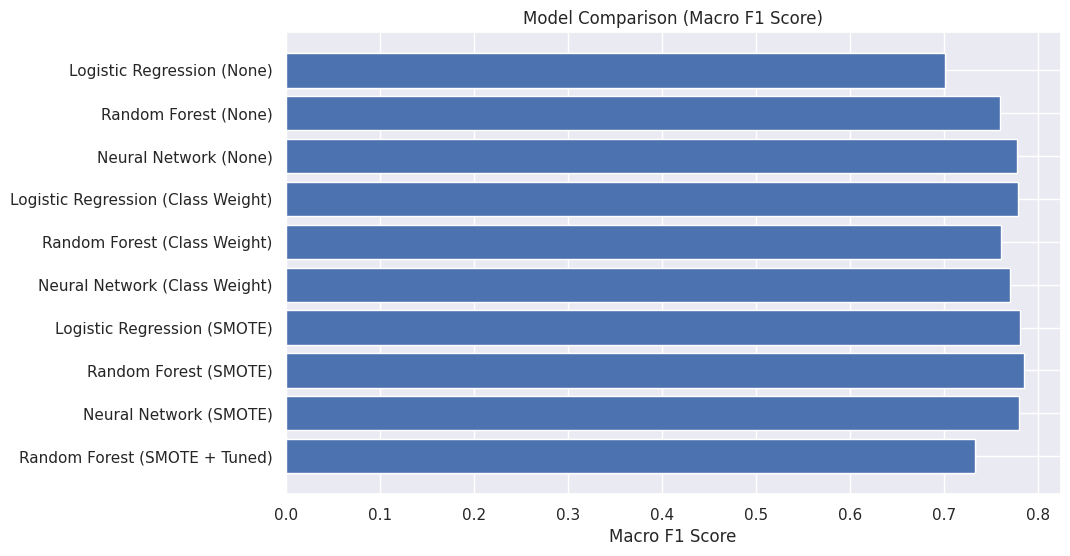

In [111]:
# =============================
# Purpose: Visualize model comparison using Macro F1 score
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['Macro_F1'])

plt.xlabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")

plt.gca().invert_yaxis()
plt.show()

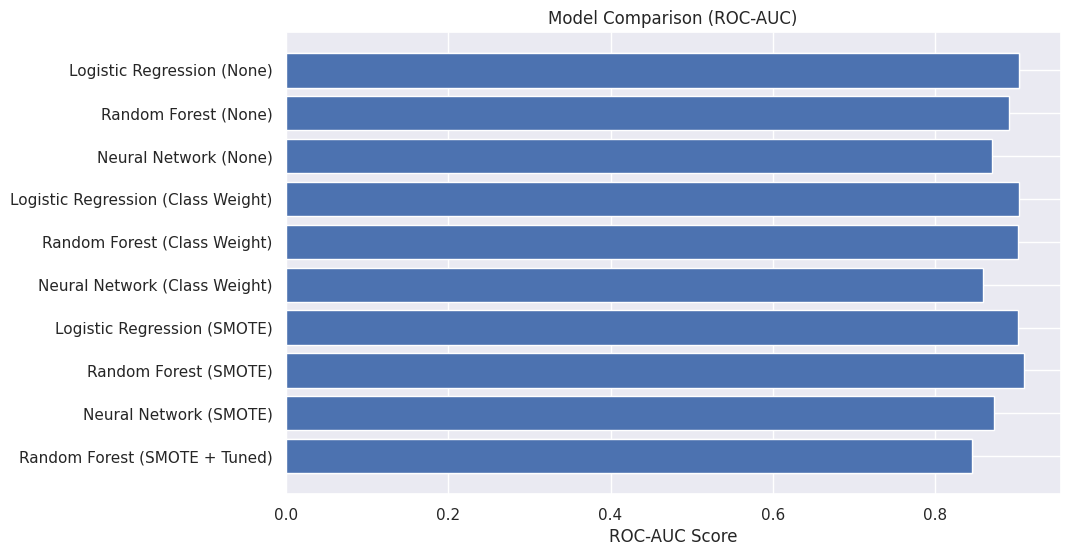

In [112]:
# =============================
# Purpose: Visualize comparison using ROC-AUC
# =============================

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['ROC_AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (ROC-AUC)")

plt.gca().invert_yaxis()
plt.show()

In [113]:
# =============================
# Purpose: Identify best performing model
# =============================

best_model = results_df_sorted.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Technique                  SMOTE
Accuracy                0.882146
Macro_F1                0.784666
Weighted_F1             0.875647
Precision_Macro         0.823353
Recall_Macro            0.758904
ROC_AUC                 0.908587
PR_AUC                  0.748312
Name: 8, dtype: object


In [114]:
# =============================
# Purpose: Perform Hyperparameter Tuning for Random Forest Classifier using GridSearchCV
# =============================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve, auc

# Define parameter grid for Random Forest
# Keeping the grid small for demonstration and faster execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
# Using 'f1_macro' as the scoring metric due to class imbalance
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3, # Using 3-fold cross-validation for speed
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the SMOTE-resampled training data
# Since RF with SMOTE performed best, we will tune that combination
print("Starting Grid Search for Random Forest...")
grid_search_rf.fit(X_train_sm, y_train_sm)
print("Grid Search complete.")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("\nBest parameters found:", grid_search_rf.best_params_)

# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro')
roc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

# Calculate additional metrics for Tuned RF
precision_rf_tuned_macro = precision_score(y_test, y_pred_rf_tuned, average='macro')
recall_rf_tuned_macro = recall_score(y_test, y_pred_rf_tuned, average='macro')
f1_rf_tuned_weighted = f1_score(y_test, y_pred_rf_tuned, average='weighted')
precision_rf_tuned_curve, recall_rf_tuned_curve, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc_rf_tuned = auc(recall_rf_tuned_curve, precision_rf_tuned_curve)

print("\nTuned Random Forest Results")
print("Accuracy:", acc_rf_tuned)
print("F1 (Macro):", f1_rf_tuned)
print("ROC-AUC:", roc_rf_tuned)

# Store results
results.append({
    "Model": "Random Forest",
    "Technique": "SMOTE + Tuned",
    "Accuracy": acc_rf_tuned,
    "Macro_F1": f1_rf_tuned,
    "Weighted_F1": f1_rf_tuned_weighted,
    "Precision_Macro": precision_rf_tuned_macro,
    "Recall_Macro": recall_rf_tuned_macro,
    "ROC_AUC": roc_rf_tuned,
    "PR_AUC": pr_auc_rf_tuned
})


Starting Grid Search for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid Search complete.

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Tuned Random Forest Results
Accuracy: 0.8548812664907651
F1 (Macro): 0.7331156776134691
ROC-AUC: 0.8451715448680863


In [115]:
results_df = pd.DataFrame(results)
results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192


In [116]:
# =============================
# Purpose: Sort models by Macro F1 score (important for imbalance)
# =============================

results_df_sorted = results_df.sort_values(by="Macro_F1", ascending=False)

results_df_sorted

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
10,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061
11,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061


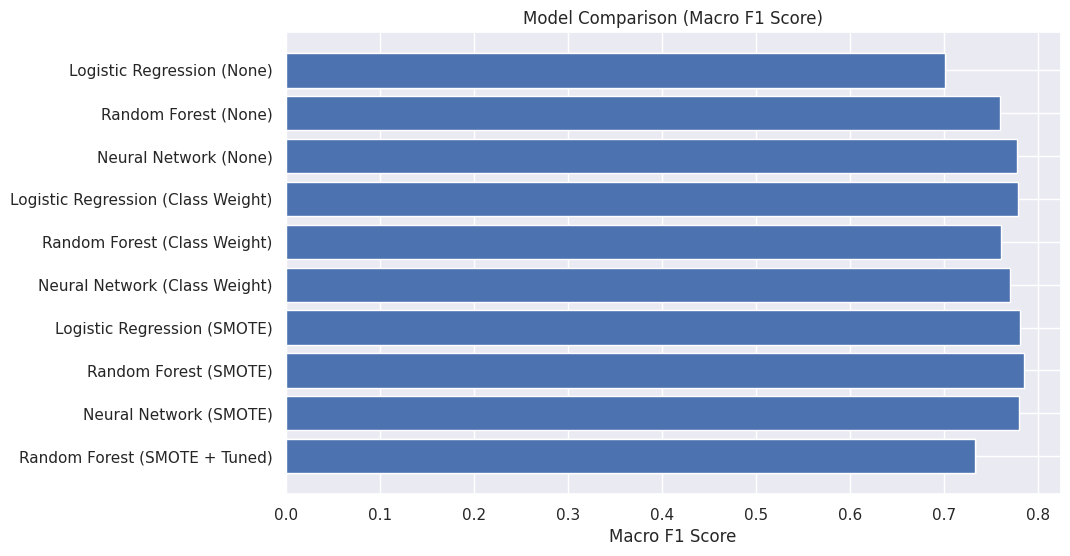

In [117]:
# =============================
# Purpose: Visualize model comparison using Macro F1 score
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['Macro_F1'])

plt.xlabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")

plt.gca().invert_yaxis()
plt.show()

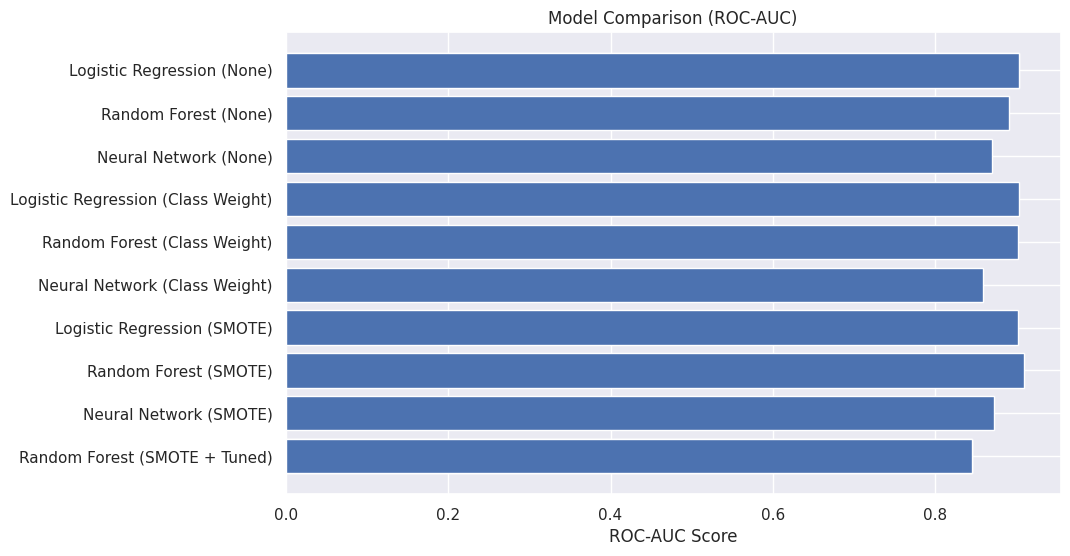

In [118]:
# =============================
# Purpose: Visualize comparison using ROC-AUC
# =============================

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['ROC_AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (ROC-AUC)")

plt.gca().invert_yaxis()
plt.show()

In [119]:
# =============================
# Purpose: Identify best performing model
# =============================

best_model = results_df_sorted.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Technique                  SMOTE
Accuracy                0.882146
Macro_F1                0.784666
Weighted_F1             0.875647
Precision_Macro         0.823353
Recall_Macro            0.758904
ROC_AUC                 0.908587
PR_AUC                  0.748312
Name: 8, dtype: object


In [120]:
# =============================
# Purpose: Perform Hyperparameter Tuning for Random Forest Classifier using GridSearchCV
# =============================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve, auc

# Define parameter grid for Random Forest
# Keeping the grid small for demonstration and faster execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
# Using 'f1_macro' as the scoring metric due to class imbalance
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3, # Using 3-fold cross-validation for speed
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the SMOTE-resampled training data
# Since RF with SMOTE performed best, we will tune that combination
print("Starting Grid Search for Random Forest...")
grid_search_rf.fit(X_train_sm, y_train_sm)
print("Grid Search complete.")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("\nBest parameters found:", grid_search_rf.best_params_)

# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro')
roc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

# Calculate additional metrics for Tuned RF
precision_rf_tuned_macro = precision_score(y_test, y_pred_rf_tuned, average='macro')
recall_rf_tuned_macro = recall_score(y_test, y_pred_rf_tuned, average='macro')
f1_rf_tuned_weighted = f1_score(y_test, y_pred_rf_tuned, average='weighted')
precision_rf_tuned_curve, recall_rf_tuned_curve, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc_rf_tuned = auc(recall_rf_tuned_curve, precision_rf_tuned_curve)

print("\nTuned Random Forest Results")
print("Accuracy:", acc_rf_tuned)
print("F1 (Macro):", f1_rf_tuned)
print("ROC-AUC:", roc_rf_tuned)

# Store results
results.append({
    "Model": "Random Forest",
    "Technique": "SMOTE + Tuned",
    "Accuracy": acc_rf_tuned,
    "Macro_F1": f1_rf_tuned,
    "Weighted_F1": f1_rf_tuned_weighted,
    "Precision_Macro": precision_rf_tuned_macro,
    "Recall_Macro": recall_rf_tuned_macro,
    "ROC_AUC": roc_rf_tuned,
    "PR_AUC": pr_auc_rf_tuned
})


Starting Grid Search for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid Search complete.

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Tuned Random Forest Results
Accuracy: 0.8548812664907651
F1 (Macro): 0.7331156776134691
ROC-AUC: 0.8451715448680863


In [121]:
results_df = pd.DataFrame(results)
results_df

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
0,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
3,Logistic Regression,None,0.864556,0.700937,0.839848,0.853372,0.660555,0.903405,0.719160
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192


In [122]:
# =============================
# Purpose: Sort models by Macro F1 score (important for imbalance)
# =============================

results_df_sorted = results_df.sort_values(by="Macro_F1", ascending=False)

results_df_sorted

,Model,Technique,Accuracy,Macro_F1,Weighted_F1,Precision_Macro,Recall_Macro,ROC_AUC,PR_AUC
8,Random Forest,SMOTE,0.882146,0.784666,0.875647,0.823353,0.758904,0.908587,0.748312
7,Logistic Regression,SMOTE,0.859279,0.780917,0.863197,0.767110,0.798660,0.901505,0.709334
9,Neural Network,SMOTE,0.869393,0.779279,0.867843,0.786235,0.772956,0.871557,0.710192
4,Logistic Regression,Class Weight,0.852243,0.778851,0.858854,0.758755,0.809840,0.903458,0.709209
2,Neural Network,None,0.872032,0.777771,0.868658,0.794021,0.764546,0.869898,0.718236
6,Neural Network,Class Weight,0.867634,0.769676,0.864001,0.786186,0.756373,0.858503,0.697978
5,Random Forest,Class Weight,0.878628,0.760801,0.866225,0.839140,0.723002,0.902063,0.737309
1,Random Forest,None,0.877309,0.759661,0.865256,0.833596,0.723103,0.891066,0.723403
10,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061
11,Random Forest,SMOTE + Tuned,0.854881,0.733116,0.846320,0.767914,0.711151,0.845172,0.628061


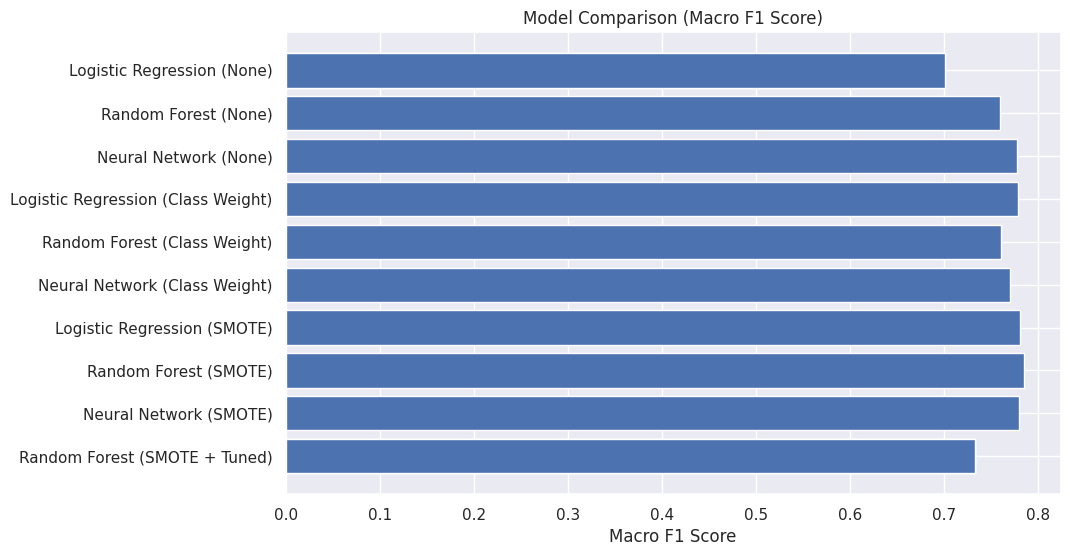

In [123]:
# =============================
# Purpose: Visualize model comparison using Macro F1 score
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['Macro_F1'])

plt.xlabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")

plt.gca().invert_yaxis()
plt.show()

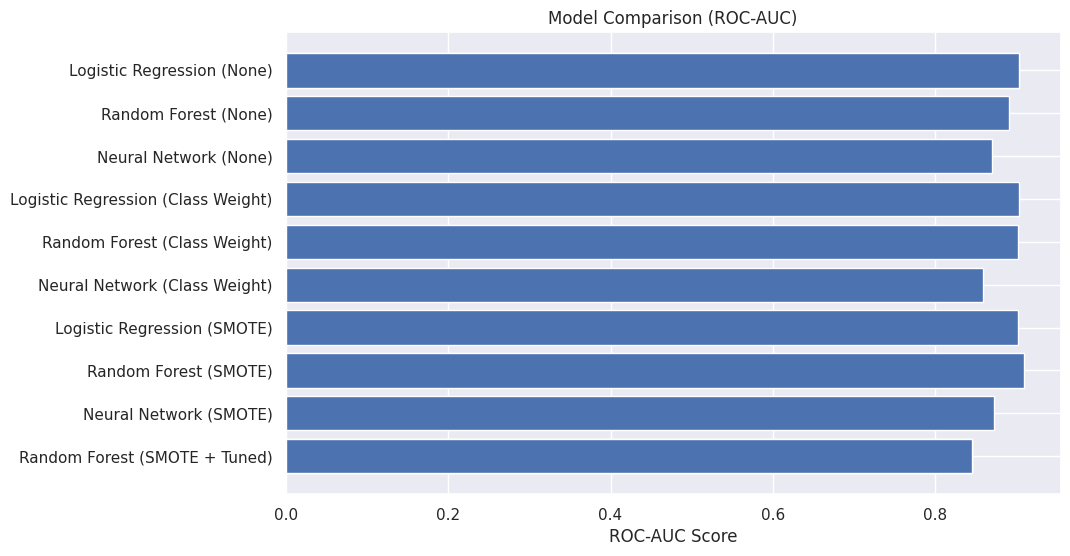

In [124]:
# =============================
# Purpose: Visualize comparison using ROC-AUC
# =============================

plt.figure(figsize=(10,6))

# Re-create labels to include the new tuned model
labels = results_df['Model'] + " (" + results_df['Technique'] + ")"

plt.barh(labels, results_df['ROC_AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (ROC-AUC)")

plt.gca().invert_yaxis()
plt.show()

In [125]:
# =============================
# Purpose: Identify best performing model
# =============================

best_model = results_df_sorted.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Technique                  SMOTE
Accuracy                0.882146
Macro_F1                0.784666
Weighted_F1             0.875647
Precision_Macro         0.823353
Recall_Macro            0.758904
ROC_AUC                 0.908587
PR_AUC                  0.748312
Name: 8, dtype: object
